This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [1]:
!pip install keras keras-hub --upgrade -q

In [2]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [3]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Classification and regression

### Classifying movie reviews: A binary classification example

#### The IMDb dataset

In [4]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000
)

In [5]:
train_data[0]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [6]:
train_labels[0]

np.int64(1)

In [7]:
max([max(sequence) for sequence in train_data])

9999

In [8]:
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_review = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[0]]
)

In [9]:
decoded_review[:100]

"? this film was just brilliant casting location scenery story direction everyone's really suited the"

#### Preparing the data

In [10]:
import numpy as np

def multi_hot_encode(sequences, num_classes):
    results = np.zeros((len(sequences), num_classes))
    for i, sequence in enumerate(sequences):
        results[i][sequence] = 1.0
    return results

x_train = multi_hot_encode(train_data, num_classes=10000)
x_test = multi_hot_encode(test_data, num_classes=10000)

In [11]:
x_train[0]

array([0., 1., 1., ..., 0., 0., 0.])

In [12]:
y_train = train_labels.astype("float32")
y_test = test_labels.astype("float32")

#### Building your model

In [13]:
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

In [14]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

#### Validating your approach

In [15]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [16]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 167ms/step - accuracy: 0.6394 - loss: 0.6308 - val_accuracy: 0.8207 - val_loss: 0.5228
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.8807 - loss: 0.4050 - val_accuracy: 0.8755 - val_loss: 0.3426
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9202 - loss: 0.2461 - val_accuracy: 0.8897 - val_loss: 0.2838
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9463 - loss: 0.1745 - val_accuracy: 0.8875 - val_loss: 0.2801
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9609 - loss: 0.1305 - val_accuracy: 0.8856 - val_loss: 0.2901
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9737 - loss: 0.0991 - val_accuracy: 0.8828 - val_loss: 0.3102
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9835 - loss: 0.0745 - val_accuracy: 0.8813 - val_loss: 0.3352
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9893 - loss: 0.0562 - val_accuracy: 0.8785 - 

In [17]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.2,
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9276 - loss: 0.2630 - val_accuracy: 0.9716 - val_loss: 0.0906
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9620 - loss: 0.1181 - val_accuracy: 0.9686 - val_loss: 0.0828
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9791 - loss: 0.0747 - val_accuracy: 0.9632 - val_loss: 0.0918
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9878 - loss: 0.0520 - val_accuracy: 0.9550 - val_loss: 0.1085
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9932 - loss: 0.0373 - val_accuracy: 0.9524 - val_loss: 0.1230
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9963 - loss: 0.0272 - val_accuracy: 0.9506 - val_loss: 0.1336
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9976 - loss: 0.0211 - val_accuracy: 0.9470 - val_loss: 0.1484
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9986 - loss: 0.0164 - val_accuracy: 0.9438 - v

In [18]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

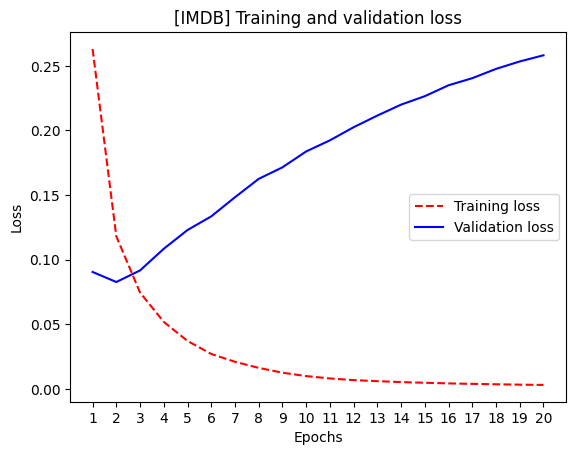

In [19]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "r--", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("[IMDB] Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

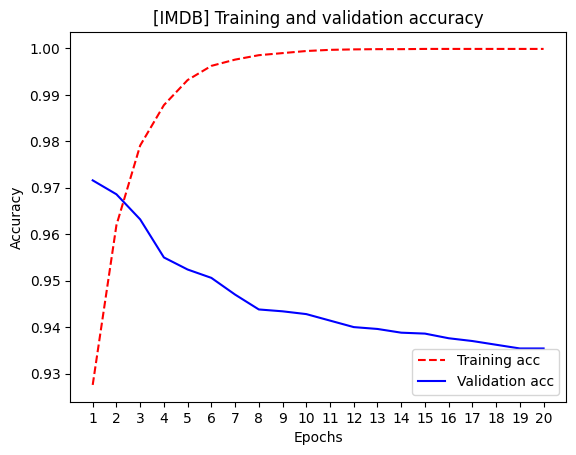

In [20]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("[IMDB] Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [21]:
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8242 - loss: 0.4387
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9184 - loss: 0.2288
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9403 - loss: 0.1711
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9527 - loss: 0.1393
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8746 - loss: 0.3313


In [22]:
results

[0.33133313059806824, 0.8745999932289124]

In [23]:
imdb_results = list(results)


#### Using a trained model to generate predictions on new data

In [24]:
model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


array([[0.22569162],
       [0.9999275 ],
       [0.88155144],
       ...,
       [0.11894418],
       [0.0725628 ],
       [0.85367095]], dtype=float32)

#### Further experiments

#### Wrapping up

### Classifying newswires: A multiclass classification example

#### The Reuters dataset

In [25]:
from keras.datasets import reuters

(train_data, train_labels), (test_data, test_labels) = reuters.load_data(
    num_words=10000
)

In [26]:
len(train_data)

8982

In [27]:
len(test_data)

2246

In [28]:
train_data[10]

[1,
 245,
 273,
 207,
 156,
 53,
 74,
 160,
 26,
 14,
 46,
 296,
 26,
 39,
 74,
 2979,
 3554,
 14,
 46,
 4689,
 4329,
 86,
 61,
 3499,
 4795,
 14,
 61,
 451,
 4329,
 17,
 12]

In [29]:
word_index = reuters.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_newswire = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[10]]
)

In [30]:
train_labels[10]

np.int64(3)

#### Preparing the data

In [31]:
x_train = multi_hot_encode(train_data, num_classes=10000)
x_test = multi_hot_encode(test_data, num_classes=10000)

In [32]:
def one_hot_encode(labels, num_classes=46):
    results = np.zeros((len(labels), num_classes))
    for i, label in enumerate(labels):
        results[i, label] = 1.0
    return results

y_train = one_hot_encode(train_labels)
y_test = one_hot_encode(test_labels)

In [33]:
from keras.utils import to_categorical

y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

#### Building your model

In [34]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)

In [35]:
top_3_accuracy = keras.metrics.TopKCategoricalAccuracy(
    k=3, name="top_3_accuracy"
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy", top_3_accuracy],
)

#### Validating your approach

In [36]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

In [37]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.4020 - loss: 3.3236 - top_3_accuracy: 0.5559 - val_accuracy: 0.5350 - val_loss: 2.6202 - val_top_3_accuracy: 0.7130
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6254 - loss: 2.0354 - top_3_accuracy: 0.7496 - val_accuracy: 0.6560 - val_loss: 1.6292 - val_top_3_accuracy: 0.7690
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7202 - loss: 1.3495 - top_3_accuracy: 0.8108 - val_accuracy: 0.7060 - val_loss: 1.2851 - val_top_3_accuracy: 0.8130
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7767 - loss: 1.0298 - top_3_accuracy: 0.8637 - val_accuracy: 0.7540 - val_loss: 1.1335 - val_top_3_accuracy: 0.8430
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8245 - loss: 0.8204 - top_3_accuracy: 0.9015 - val_accuracy: 0.7770 - val_loss: 1.0421 - val_top_3_accuracy: 0.8810
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8614 - loss: 0.6531 - top_3_a

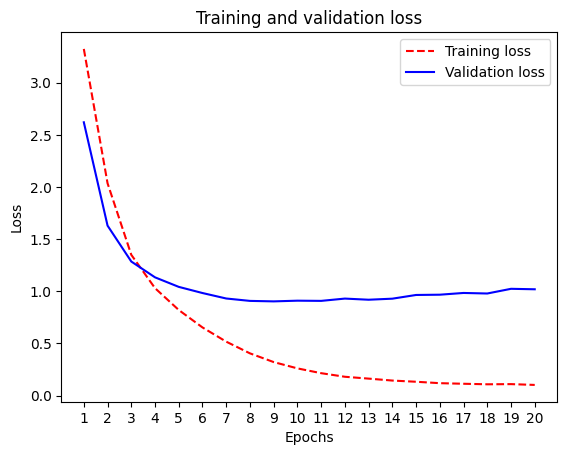

In [38]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

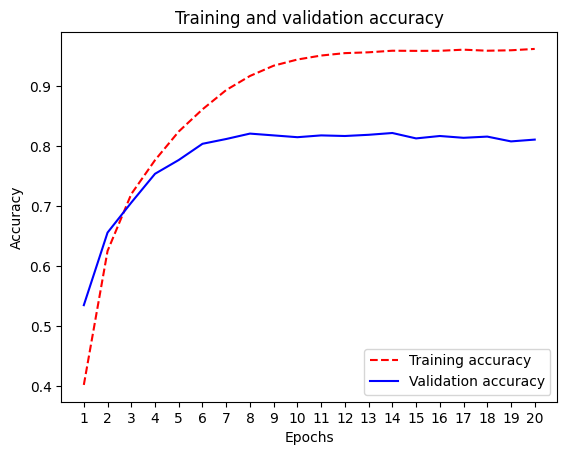

In [39]:
plt.clf()
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

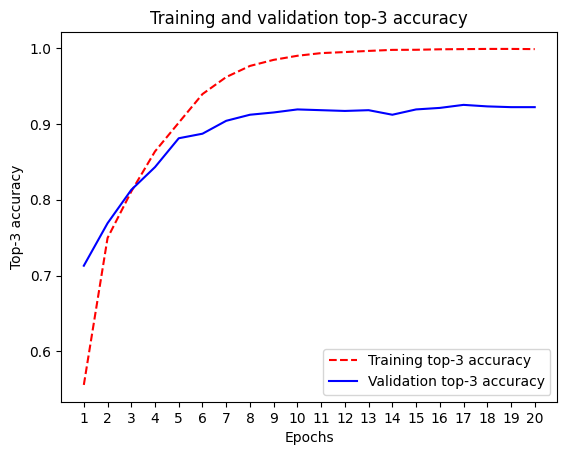

In [40]:
plt.clf()
acc = history.history["top_3_accuracy"]
val_acc = history.history["val_top_3_accuracy"]
plt.plot(epochs, acc, "r--", label="Training top-3 accuracy")
plt.plot(epochs, val_acc, "b", label="Validation top-3 accuracy")
plt.title("Training and validation top-3 accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Top-3 accuracy")
plt.legend()
plt.show()

In [41]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    x_train,
    y_train,
    epochs=9,
    batch_size=512,
)
results = model.evaluate(x_test, y_test)

Epoch 1/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.4826 - loss: 3.2112
Epoch 2/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6393 - loss: 1.8198
Epoch 3/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7410 - loss: 1.2272
Epoch 4/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7998 - loss: 0.9303
Epoch 5/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8518 - loss: 0.7152
Epoch 6/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8912 - loss: 0.5518
Epoch 7/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9137 - loss: 0.4256
Epoch 8/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9287 - loss: 0.3322
Epoch 9/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9378 - loss: 0.2651
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8019 - loss: 0.9185


In [42]:
results

[0.9185446500778198, 0.8018699884414673]

In [43]:
reuters_results = list(results)


In [44]:
import copy
test_labels_copy = copy.copy(test_labels)
np.random.shuffle(test_labels_copy)
hits_array = np.array(test_labels == test_labels_copy)
hits_array.mean()

np.float64(0.18121104185218165)

#### Generating predictions on new data

In [45]:
predictions = model.predict(x_test)

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [46]:
predictions[0].shape

(46,)

In [47]:
np.sum(predictions[0])

np.float32(1.0000001)

In [48]:
np.argmax(predictions[0])

np.int64(3)

#### A different way to handle the labels and the loss

In [49]:
y_train = train_labels
y_test = test_labels

In [50]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

#### The importance of having sufficiently large intermediate layers

In [51]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(4, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_val, y_val),
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.3773 - loss: 3.0155 - val_accuracy: 0.5770 - val_loss: 2.2325
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6006 - loss: 1.8892 - val_accuracy: 0.6150 - val_loss: 1.6934
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6237 - loss: 1.5567 - val_accuracy: 0.6110 - val_loss: 1.6069
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6314 - loss: 1.4443 - val_accuracy: 0.6150 - val_loss: 1.5810
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6404 - loss: 1.3743 - val_accuracy: 0.6210 - val_loss: 1.5748
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6515 - loss: 1.3119 - val_accuracy: 0.6160 - val_loss: 1.5570
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6590 - loss: 1.2142 - val_accuracy: 0.6250 - val_loss: 1.5072
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6926 - loss: 1.0909 - val_accuracy: 0.6430 - val_loss

#### Further experiments

#### Wrapping up

### Predicting house prices: A regression example

#### The California Housing Price dataset

In [52]:
from keras.datasets import california_housing

(train_data, train_targets), (test_data, test_targets) = (
    california_housing.load_data(version="small")
)

In [53]:
train_data.shape

(480, 8)

In [54]:
test_data.shape

(120, 8)

In [55]:
train_targets

array([228400., 132900.,  60000.,  95200., 107000., 122500., 132000.,
       290100., 257800., 390100., 220800., 284900.,  97500., 415300.,
        84200., 185600., 216700., 233100., 127000., 182300.,  92300.,
        90700., 102100., 112500., 350700., 156500., 220700., 147400.,
       216700., 275000., 198200., 119100., 289500., 152500., 125000.,
       104500.,  93800.,  89300., 452600., 128600., 311500.,  90000.,
       218200., 131300.,  67500., 139400., 500001., 182600., 111300.,
       112500., 134700.,  71300., 207400., 331400., 107900.,  87500.,
       342200.,  87100., 314700., 368600., 211600., 338900., 366100.,
       164300.,  91700., 261400., 218500., 155400., 273700.,  81800.,
       138800.,  99700., 156300., 140600., 152700., 108900., 351200.,
       126000., 137500., 196900., 240000., 172800., 254200.,  97500.,
       182700., 162500.,  86100., 226700., 412500., 165900., 327100.,
       162500., 188800., 183800.,  90600., 372000., 275000., 151800.,
       125000., 1291

#### Preparing the data

In [56]:
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)
x_train = (train_data - mean) / std
x_test = (test_data - mean) / std

In [57]:
y_train = train_targets / 100000
y_test = test_targets / 100000

#### Building your model

In [58]:
def get_model():
    model = keras.Sequential(
        [
            layers.Dense(64, activation="relu"),
            layers.Dense(64, activation="relu"),
            layers.Dense(1),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="mean_squared_error",
        metrics=["mean_absolute_error"],
    )
    return model

#### Validating your approach using K-fold validation

In [59]:
k = 4
num_val_samples = len(x_train) // k
num_epochs = 50
all_scores = []
for i in range(k):
    print(f"Processing fold #{i + 1}")
    fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_x_train = np.concatenate(
        [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    model = get_model()
    model.fit(
        fold_x_train,
        fold_y_train,
        epochs=num_epochs,
        batch_size=16,
        verbose=0,
    )
    scores = model.evaluate(fold_x_val, fold_y_val, verbose=0)
    val_loss, val_mae = scores
    all_scores.append(val_mae)

Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


In [60]:
[round(value, 3) for value in all_scores]

[0.308, 0.298, 0.233, 0.326]

In [61]:
round(np.mean(all_scores), 3)

np.float64(0.291)

In [62]:
k = 4
num_val_samples = len(x_train) // k
num_epochs = 200
all_mae_histories = []
for i in range(k):
    print(f"Processing fold #{i + 1}")
    fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_x_train = np.concatenate(
        [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    model = get_model()
    history = model.fit(
        fold_x_train,
        fold_y_train,
        validation_data=(fold_x_val, fold_y_val),
        epochs=num_epochs,
        batch_size=16,
        verbose=0,
    )
    mae_history = history.history["val_mean_absolute_error"]
    all_mae_histories.append(mae_history)

Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


In [63]:
average_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)
]

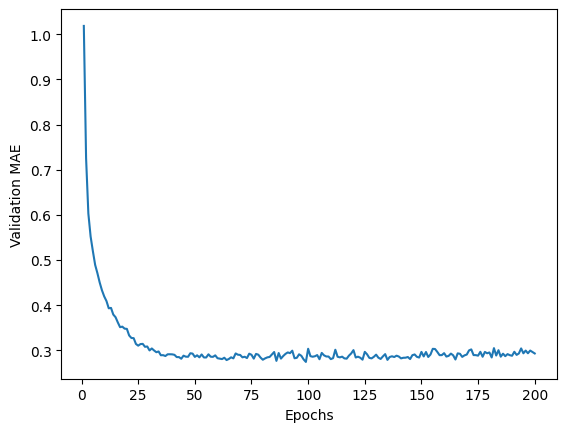

In [64]:
epochs = range(1, len(average_mae_history) + 1)
plt.plot(epochs, average_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

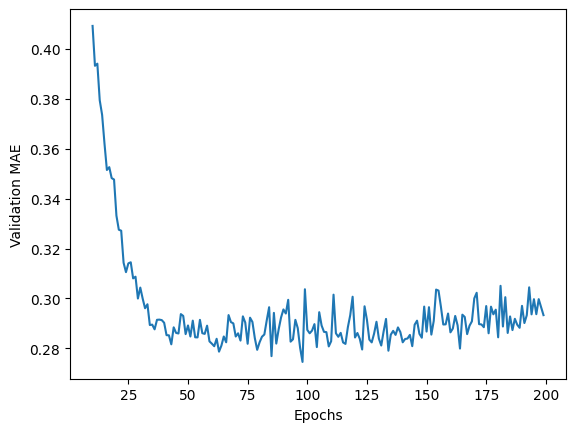

In [65]:
truncated_mae_history = average_mae_history[10:]
epochs = range(10, len(truncated_mae_history) + 10)
plt.plot(epochs, truncated_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

In [66]:
model = get_model()
model.fit(x_train, y_train, epochs=130, batch_size=16, verbose=0)
test_mean_squared_error, test_mean_absolute_error = model.evaluate(
    x_test, y_test
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.2871 - mean_absolute_error: 0.3118


In [67]:
round(test_mean_absolute_error, 3)

0.312

#### Generating predictions on new data

In [68]:
predictions = model.predict(x_test)
predictions[0]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


array([2.4980977], dtype=float32)

#### Wrapping up

In [69]:
# ============================================================
# FINAL EVALUATE SONUÇLARI
# ============================================================
print("1) IMDB Binary Classification - Evaluate:")
print(f"   Loss: {imdb_results[0]:.4f}, Accuracy: {imdb_results[1]:.4f}")
print()
print("2) Reuters Multi-class Classification - Evaluate:")
print(f"   Loss: {reuters_results[0]:.4f}, Accuracy: {reuters_results[1]:.4f}")
print()
print("3) CALIFORNIA HOUSING - Final Evaluate:")
test_mse, test_mae = model.evaluate(x_test, y_test, verbose=0)
print(f"   Test MSE: {test_mse:.4f}")
print(f"   Test MAE: {test_mae:.4f}")
print()

# ============================================================
# ÖĞRENCİ BİLGİLERİ
# ============================================================
print("İsim: UTKU MERT GEÇGEL")
print("Tarih: 2 Mart 2026")
print()
print("BONUS ÇALIŞMALAR İÇİN GITHUB FORK LİNKİ:")
print("https://github.com/utkumertgecgel/deep-learning-with-python-notebooks/blob/master/chapter04_classification-and-regression.ipynb")
print("Yapılan bonuslar: Dropout karşılaştırması, Early Stopping, Confusion Matrix")
print()

# ============================================================
# YORUMLAR (5 Adet)
# ============================================================
print("YORUM 1: IMDB veri seti 50K film yorumundan oluşur. num_words=10000 ile")
print("en sık 10K kelime alınır. Etiketler binary: 0=olumsuz, 1=olumlu.")
print()
print("YORUM 2: Multi-hot encoding ile değişken uzunluktaki diziler 10000")
print("boyutlu sabit vektörlere dönüştürülür. Dezavantajı: kelime sırası kaybolur.")
print()
print("YORUM 3: Training loss azalırken validation loss epoch 4'ten sonra artıyor.")
print("Bu overfitting göstergesidir. Dropout veya Early Stopping ile önlenebilir.")
print()
print("YORUM 4: 46 kategorili Reuters sınıflandırmasında softmax aktivasyonu")
print("kullanılır. Softmax her sınıf için olasılık üretir, toplamları 1 eder.")
print()
print("YORUM 5: California Housing küçük veri seti olduğu için K-Fold CV (k=4)")
print("ile daha güvenilir performans ölçümü yapılır. Veri normalize edilir")
print("çünkü özellikler farklı ölçeklerdedir.")


1) IMDB Binary Classification - Evaluate:
   Loss: 0.3313, Accuracy: 0.8746

2) Reuters Multi-class Classification - Evaluate:
   Loss: 0.9185, Accuracy: 0.8019

3) CALIFORNIA HOUSING - Final Evaluate:
   Test MSE: 0.2871
   Test MAE: 0.3118

İsim: UTKU MERT GEÇGEL
Tarih: 2 Mart 2026

BONUS ÇALIŞMALAR İÇİN GITHUB FORK LİNKİ:
https://github.com/utkumertgecgel/deep-learning-with-python-notebooks/blob/master/chapter04_classification-and-regression.ipynb
Yapılan bonuslar: Dropout karşılaştırması, Early Stopping, Confusion Matrix

YORUM 1: IMDB veri seti 50K film yorumundan oluşur. num_words=10000 ile
en sık 10K kelime alınır. Etiketler binary: 0=olumsuz, 1=olumlu.

YORUM 2: Multi-hot encoding ile değişken uzunluktaki diziler 10000
boyutlu sabit vektörlere dönüştürülür. Dezavantajı: kelime sırası kaybolur.

YORUM 3: Training loss azalırken validation loss epoch 4'ten sonra artıyor.
Bu overfitting göstergesidir. Dropout veya Early Stopping ile önlenebilir.

YORUM 4: 46 kategorili Reuters sın

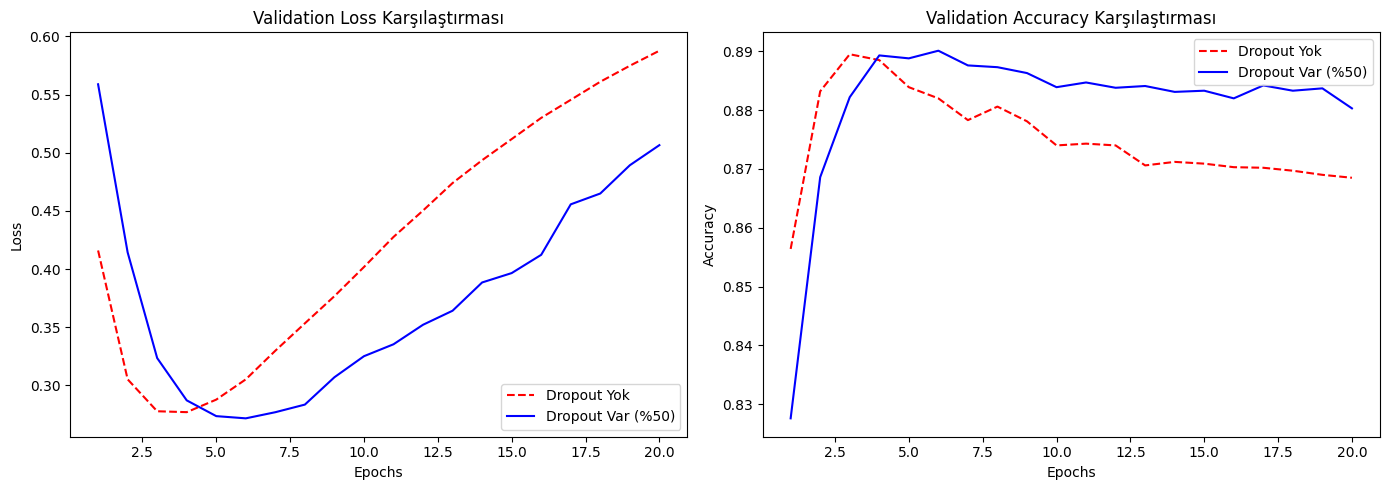

SONUÇ: Dropout ile validation loss artışı gecikiyor → overfitting azalıyor!


In [70]:
# ============================================================
# BONUS 1: Dropout ile Overfitting Önleme
# Dropout, eğitim sırasında rastgele nöronları devre dışı bırakarak
# modelin ezberlemeisni (overfitting) önler.
# ============================================================
import keras
from keras import layers
import matplotlib.pyplot as plt
from keras.datasets import imdb
import numpy as np

# Veri hazırlama
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

def multi_hot_encode(sequences, num_classes):
    results = np.zeros((len(sequences), num_classes))
    for i, sequence in enumerate(sequences):
        results[i][sequence] = 1.0
    return results

x_train = multi_hot_encode(train_data, num_classes=10000)
x_test = multi_hot_encode(test_data, num_classes=10000)
y_train = train_labels.astype("float32")
y_test = test_labels.astype("float32")

x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

# Dropout'suz model
model_no_drop = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])
model_no_drop.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history_no_drop = model_no_drop.fit(partial_x_train, partial_y_train,
    epochs=20, batch_size=512, validation_data=(x_val, y_val), verbose=0)

# Dropout'lu model
model_drop = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid"),
])
model_drop.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history_drop = model_drop.fit(partial_x_train, partial_y_train,
    epochs=20, batch_size=512, validation_data=(x_val, y_val), verbose=0)

# Karşılaştırma Grafikleri
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, 21)

ax1.plot(epochs, history_no_drop.history["val_loss"], "r--", label="Dropout Yok")
ax1.plot(epochs, history_drop.history["val_loss"], "b-", label="Dropout Var (%50)")
ax1.set_title("Validation Loss Karşılaştırması")
ax1.set_xlabel("Epochs"); ax1.set_ylabel("Loss"); ax1.legend()

ax2.plot(epochs, history_no_drop.history["val_accuracy"], "r--", label="Dropout Yok")
ax2.plot(epochs, history_drop.history["val_accuracy"], "b-", label="Dropout Var (%50)")
ax2.set_title("Validation Accuracy Karşılaştırması")
ax2.set_xlabel("Epochs"); ax2.set_ylabel("Accuracy"); ax2.legend()

plt.tight_layout()
plt.show()

print("SONUÇ: Dropout ile validation loss artışı gecikiyor → overfitting azalıyor!")


In [71]:
# ============================================================
# BONUS 2: Early Stopping ile Otomatik En İyi Epoch Bulma
# Validation loss artmaya başlayınca eğitimi otomatik durdurur
# ve en iyi ağırlıkları geri yükler.
# ============================================================
from keras.callbacks import EarlyStopping

model_es = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])
model_es.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history_es = model_es.fit(partial_x_train, partial_y_train,
    epochs=50, batch_size=512,
    validation_data=(x_val, y_val),
    callbacks=[early_stop])

best_epoch = len(history_es.history["loss"])
results_es = model_es.evaluate(x_test, y_test)
print(f"\nEarly Stopping ile en iyi epoch: {best_epoch}")
print(f"Test Loss: {results_es[0]:.4f}")
print(f"Test Accuracy: {results_es[1]:.4f}")
print(f"\nSONUÇ: 50 epoch yerine sadece {best_epoch} epoch'ta durdu, overfitting önlendi!")


Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.7439 - loss: 0.5870 - val_accuracy: 0.8547 - val_loss: 0.4416
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8948 - loss: 0.3368 - val_accuracy: 0.8834 - val_loss: 0.3088
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9253 - loss: 0.2211 - val_accuracy: 0.8891 - val_loss: 0.2773
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9461 - loss: 0.1638 - val_accuracy: 0.8881 - val_loss: 0.2790
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9624 - loss: 0.1242 - val_accuracy: 0.8839 - val_loss: 0.2926
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9738 - loss: 0.0965 - val_accuracy: 0.8812 - val_loss: 0.3092
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8804 - loss: 0.2953

Early Stopping ile en iyi epoch: 6
Test Loss: 0.2953
Test Accuracy: 0.8804

SONUÇ: 50 epoch yerine sadece 6 epoch'ta durdu, overfitting önlendi!


782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


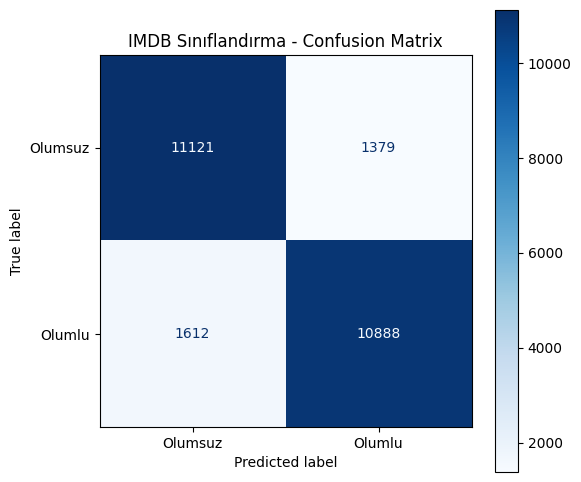


Classification Report:
              precision    recall  f1-score   support

     Olumsuz       0.87      0.89      0.88     12500
      Olumlu       0.89      0.87      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



In [72]:
# ============================================================
# BONUS 3: Confusion Matrix ve Classification Report
# Modelin hangi sınıfları doğru/yanlış tahmin ettiğini gösterir.
# Precision, Recall ve F1-Score metrikleri hesaplanır.
# ============================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

predictions = (model_es.predict(x_test) > 0.5).astype("int32").flatten()

cm = confusion_matrix(y_test.astype(int), predictions)
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(cm, display_labels=["Olumsuz", "Olumlu"])
disp.plot(ax=ax, cmap="Blues")
plt.title("IMDB Sınıflandırma - Confusion Matrix")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test.astype(int), predictions,
                            target_names=["Olumsuz", "Olumlu"]))
